# Matplotlib 是什麼？
Matplotlib 是 Python 中最常用的繪圖函式庫，讓你能夠將數據畫成圖表。它就像 Python 的畫布工具，能畫出線圖、長條圖、散點圖、直方圖等各種視覺化結果。

# 引入Library

In [1]:
import matplotlib.pyplot as plt

# 基本指令


1.   plt.title("標題") : 加標題
2.   plt.xlabel("X軸") : X軸標籤
3.   plt.ylabel("Y軸") : Y軸標籤
4.   plt.plot(x, y)  : 折線圖
5.   plt.scatter(x, y) : 散點圖
6.   plt.bar(x, y)  : 長條圖
7.   plt.show()    : 顯示圖
8.   plt.grid(True)  : 顯示網格


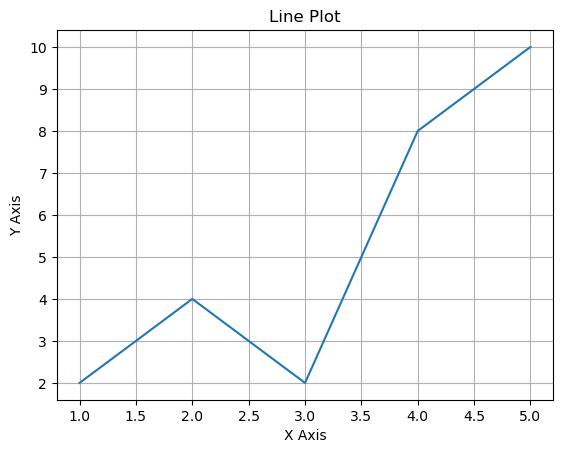

In [2]:
x = [1, 2, 3, 4, 5]
y = [2, 4, 2, 8, 10]


plt.plot(x, y)
plt.title("Line Plot")
plt.xlabel("X Axis")
plt.ylabel("Y Axis")
plt.grid(True)
plt.show()

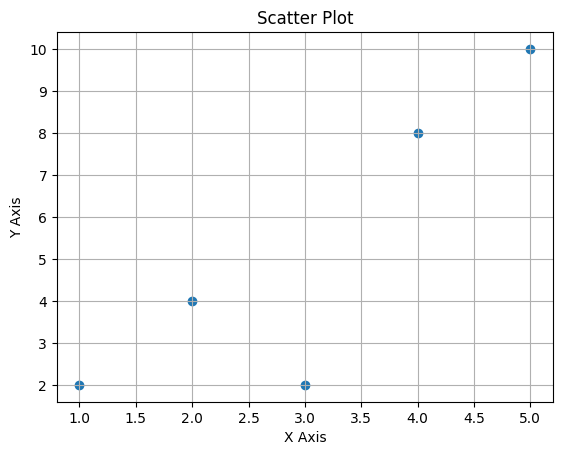

In [ ]:
plt.scatter(x, y)
plt.title("Scatter Plot")
plt.xlabel("X Axis")
plt.ylabel("Y Axis")
plt.grid(True)
plt.show()

# 圖表細節設計


1.   plt.xlim() : X軸範圍
2.   plt.ylim() : Y軸範圍
3.   plt.legend() : 圖示
4.   plt.text() : 註解



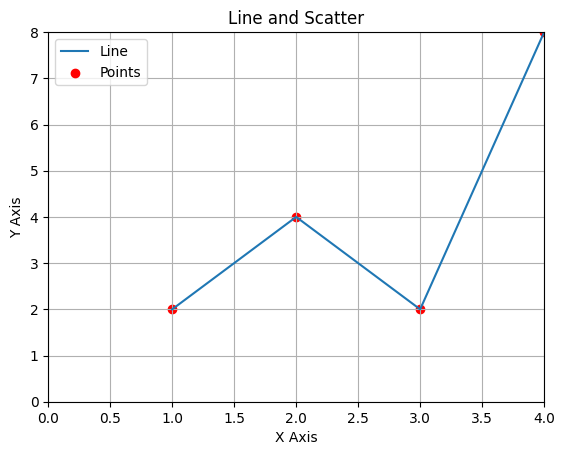

In [ ]:
plt.plot(x, y, label='Line')
plt.scatter(x, y, color='red', label='Points')

plt.title("Line and Scatter")
plt.xlabel("X Axis")
plt.ylabel("Y Axis")

plt.xlim(0, 4)
plt.ylim(0, 8)


plt.legend()
plt.grid(True)
plt.show()

# 畫函數圖

## $y=x ^ 2$

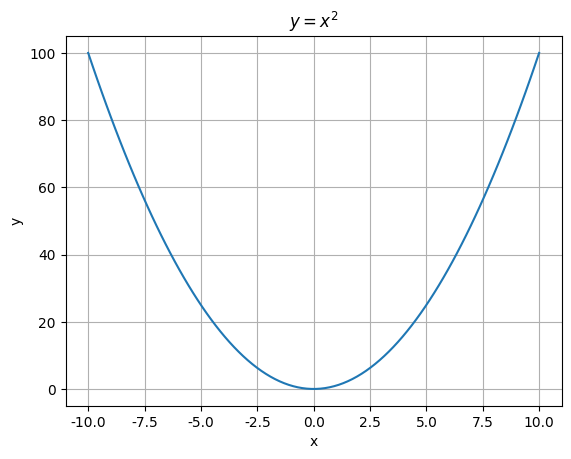

In [ ]:
import numpy as np

x = np.linspace(-10, 10, 100)
y = x ** 2

plt.plot(x, y)
plt.title(r"$y = x^2$")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

## $y = sin(x)$

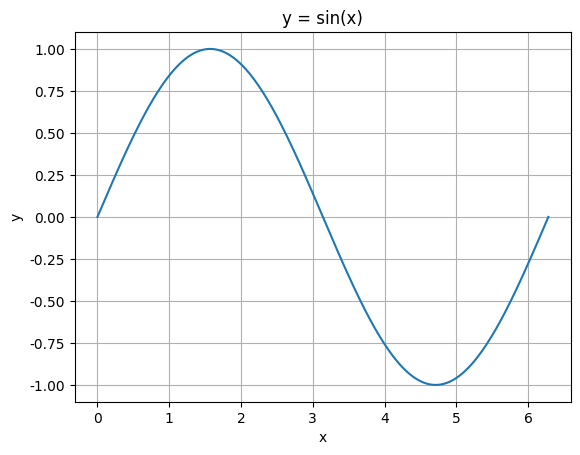

In [ ]:
x = np.linspace(0, 2 * np.pi, 300)
y = np.sin(x)

plt.plot(x, y)
plt.title("y = sin(x)")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

## 常態分布

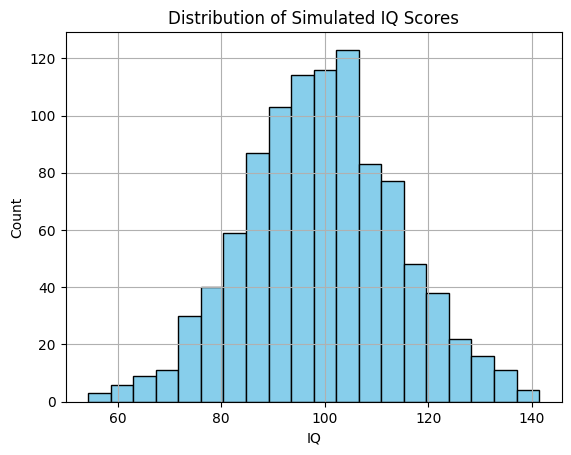

In [ ]:
np.random.seed(0)
iq = np.random.normal(100, 15, 1000)  # 平均100、標準差15

plt.hist(iq, bins=20, color='skyblue', edgecolor='black')
plt.title("Distribution of Simulated IQ Scores")
plt.xlabel("IQ")
plt.ylabel("Count")
plt.grid(True)
plt.show()


# 實戰演練

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)
n = 200

ages = np.random.normal(35, 7, n).clip(20, 60).astype(int)

genders = np.random.choice(["Male", "Female"], n)

income = (
    30000 +
    ages * 800 +
    np.where(genders == "Male", 5000, 0) +
    np.random.normal(0, 3000, n)
).astype(int)


df = pd.DataFrame({
    "age": ages,
    "gender": genders,
    "income": income
})

print(df.head())

   age  gender  income
0   38  Female   59944
1   34  Female   58964
2   39    Male   67042
3   45  Female   64131
4   33    Male   60775


## 年齡分布（直方圖）

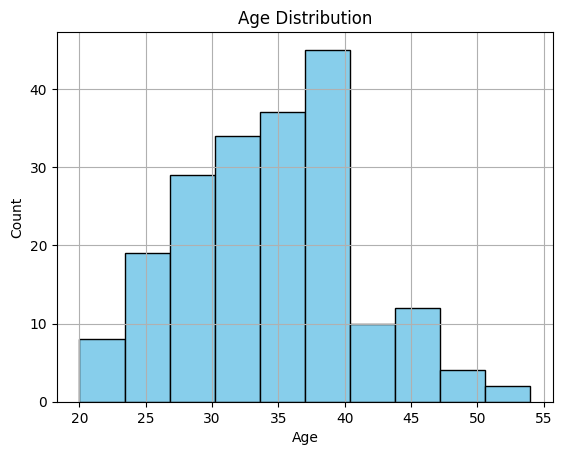

In [ ]:
plt.hist(df["age"], bins=10, color="skyblue", edgecolor="black")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.grid(True)
plt.show()

## 性別與平均收入（長條圖）

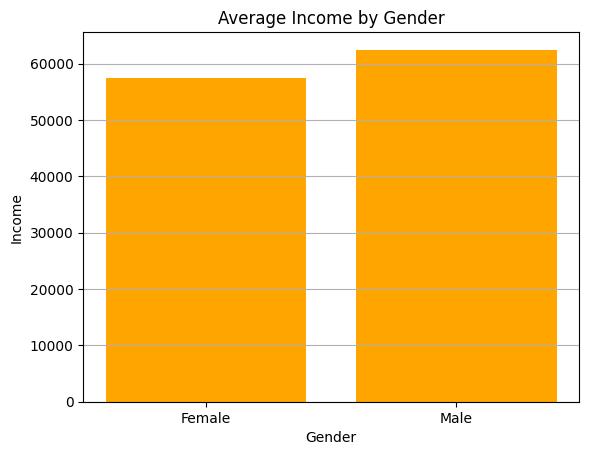

In [ ]:
mean_income = df.groupby("gender")["income"].mean()

plt.bar(mean_income.index, mean_income.values, color="orange")
plt.title("Average Income by Gender")
plt.xlabel("Gender")
plt.ylabel("Income")
plt.grid(True, axis="y")
plt.show()

## 年齡 vs 收入

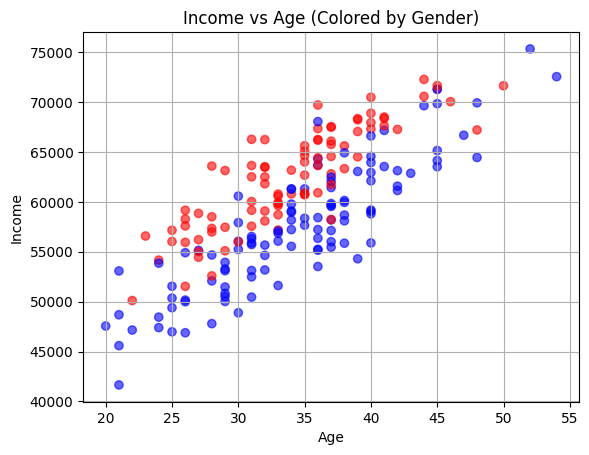

In [ ]:
plt.scatter(df["age"], df["income"], c=(df["gender"] == "Male"), cmap="bwr", alpha=0.6)
plt.title("Income vs Age (Colored by Gender)")
plt.xlabel("Age")
plt.ylabel("Income")
plt.grid(True)
plt.show()

## 機器學習實例

### 準備資料 + 訓練模型

In [9]:
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 載入資料（只取前兩類別，變成 binary 分類）
iris = load_iris()
X = iris.data
y = iris.target

# 只保留類別 0 和 1
mask = y < 2
X = X[mask]
y = y[mask]

# 標準化資料
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 切分訓練/測試資料
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 訓練邏輯回歸模型
model = LogisticRegression()
model.fit(X_train, y_train)


LogisticRegression()

### 計算 ROC 曲線 & AUC 分數

In [11]:
# 預測機率
y_score = model.predict_proba(X_test)[:, 1]

# 計算 ROC 曲線座標
fpr, tpr, thresholds = roc_curve(y_test, y_score)

# 計算 AUC
auc_score = roc_auc_score(y_test, y_score)

### 畫出 ROC 曲線

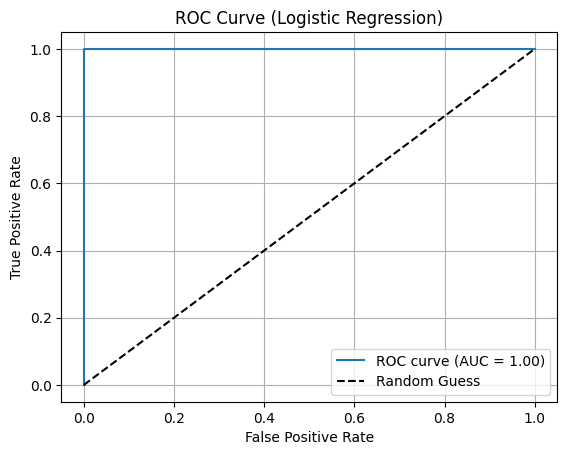

In [12]:
plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Logistic Regression)")
plt.legend()
plt.grid(True)
plt.show()

## 神經網路

### . 載入資料與預處理（PCA 降維）

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 讀取 Iris 資料
iris = load_iris()
X = iris.data
y = iris.target

# 標準化
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 降維到 2 維（方便視覺化）
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# 切分資料
X_train, X_val, y_train, y_val = train_test_split(X_pca, y, test_size=0.2, random_state=42)

# 轉為 tensor
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)

### 建立簡單神經網路模型

In [6]:
model = nn.Sequential(
    nn.Linear(2, 8),
    nn.ReLU(),
    nn.Linear(8, 3)
)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)


###  訓練模型，記錄 Loss

In [7]:
train_losses = []

for epoch in range(100):
    y_pred = model(X_train)
    loss = loss_fn(y_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

### 畫出分類結果（PCA 降維視覺化）

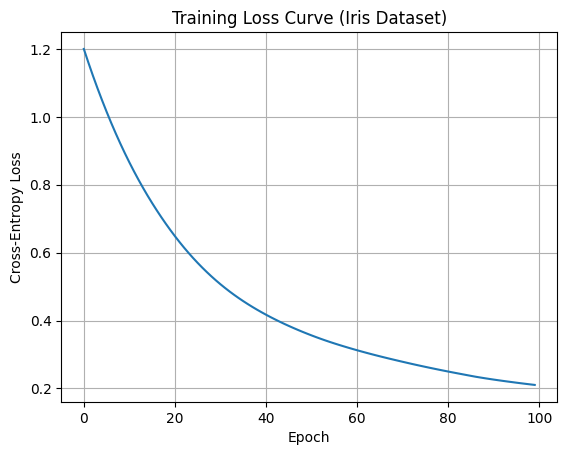

In [8]:
plt.plot(train_losses)
plt.title("Training Loss Curve (Iris Dataset)")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.grid(True)
plt.show()

# Seaborn

內建風格
1. sns.set_style("whitegrid") : 預設，白色格線
2. sns.set_style("darkgrid")  :   黑色背景+灰格線
3. sns.set_style("white")    :   純白背景，沒有格線
4. sns.set_style("dark")     :   全暗背景
5. sns.set_style("ticks")     :   有刻度標示風格

色盤
1. sns.set_palette("pastel")  :    柔和
2. sns.set_palette("deep")   :     深色（預設）
3. sns.set_palette("muted")  :    柔色
4. sns.set_palette("bright")  :   鮮豔
5. sns.set_palette("dark")   :   暗色


# 引入Library

In [ ]:
import seaborn as sns

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


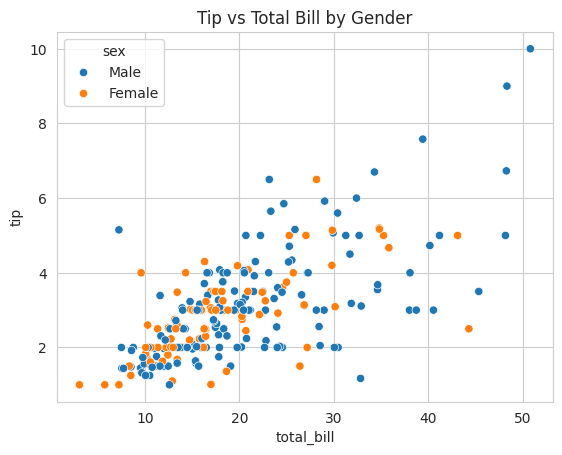

In [ ]:
tips = sns.load_dataset("tips")

print(tips.head())

sns.scatterplot(x="total_bill", y="tip", hue="sex", data=tips)
plt.title("Tip vs Total Bill by Gender")
plt.show()

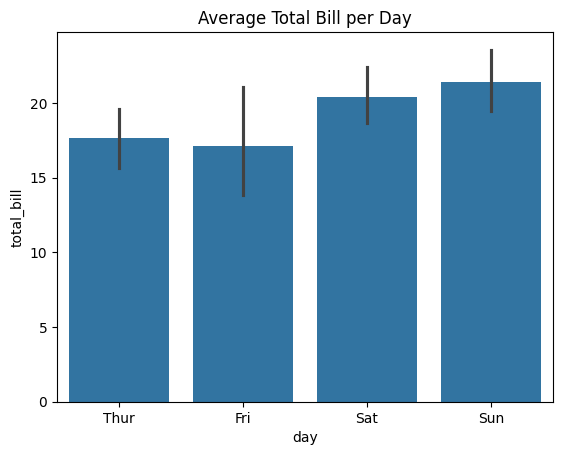

In [ ]:
sns.barplot(x="day", y="total_bill", data=tips) # tips.groupby("day")["total_bill"].mean() #信賴區間(Cl)
plt.title("Average Total Bill per Day")
plt.show()

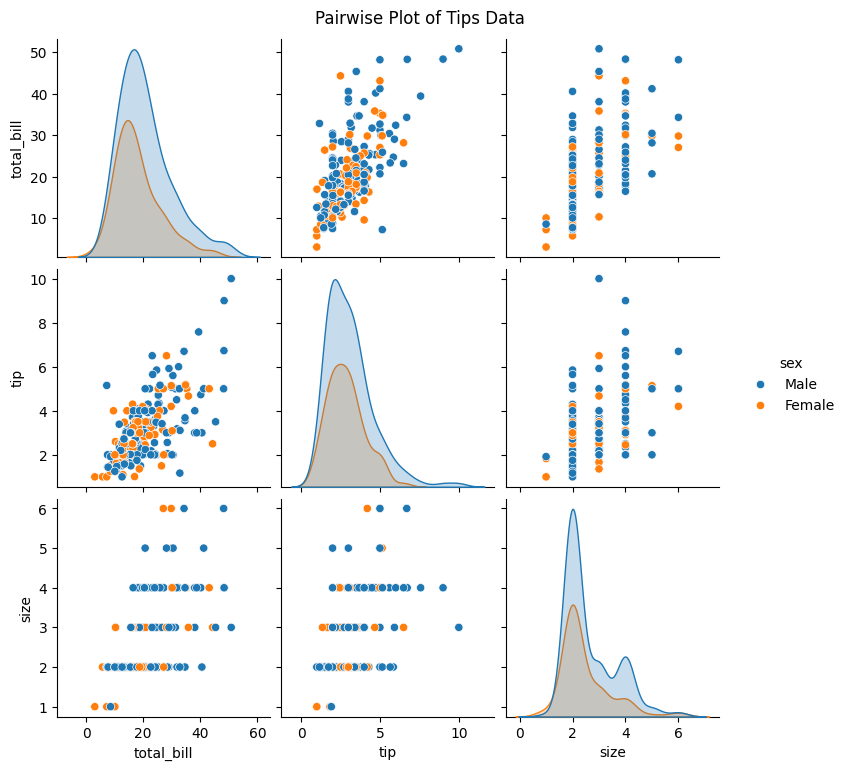

In [ ]:
sns.pairplot(tips, hue="sex")
plt.suptitle("Pairwise Plot of Tips Data", y=1.02)
plt.show()

# 小試身手，試著畫出直方圖

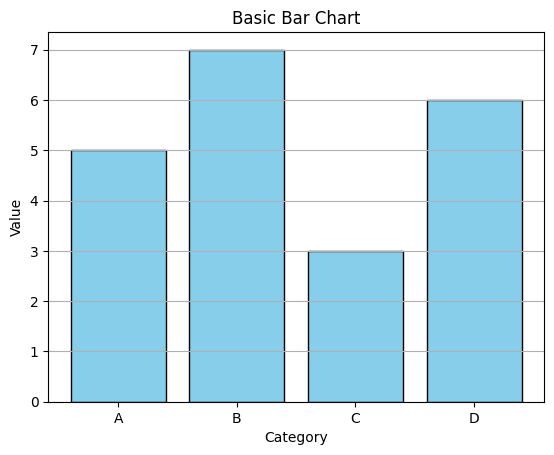